<a href="https://colab.research.google.com/github/sathu0622/DL_Assigment/blob/feature%2Fabishaan/CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Introduction**

This project implements a Convolutional Neural Network (CNN) to classify images from the Fashion MNIST dataset — a collection of 70,000 grayscale images of 10 different clothing categories such as shirts, sneakers, and coats.

The CNN model automatically learns visual patterns such as edges, textures, and shapes from raw pixel data, making it well-suited for image recognition tasks.

In this implementation:

* The dataset is preprocessed by normalizing pixel values and reshaping images to fit the CNN input format.

* The model architecture includes multiple convolutional and max-pooling layers to capture spatial hierarchies in the data.

* Fully connected layers are used to perform the final classification across 10 clothing categories.

* The model is trained using the Adam optimizer with the sparse categorical cross-entropy loss function for multi-class classification.

* Finally, the performance of the CNN is evaluated on the test dataset, and accuracy trends are visualized using training and validation metrics.


This approach demonstrates how deep learning can be applied to fashion image classification using TensorFlow and Keras.


# **Import Required Libraries**

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import fashion_mnist
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


# **Load and Preprocess the Dataset**

In [2]:
# Load dataset
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Reshape and normalize
x_train_cnn = x_train.reshape(-1, 28, 28, 1) / 255.0
x_test_cnn = x_test.reshape(-1, 28, 28, 1) / 255.0

print("Training data shape:", x_train_cnn.shape)
print("Testing data shape:", x_test_cnn.shape)


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28, 1)
Testing data shape: (10000, 28, 28, 1)


# **Build the CNN Model**

In [3]:
model2 = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

model2.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

# **Compile the Model**

In [4]:
model2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# **Train the Model**

In [5]:
history2 = model2.fit(
    x_train_cnn, y_train,
    epochs=6,
    validation_data=(x_test_cnn, y_test)
)

Epoch 1/6
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 68s 34ms/step - accuracy: 0.7547 - loss: 0.6873 - val_accuracy: 0.8668 - val_loss: 0.3610
Epoch 2/6
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 61s 33ms/step - accuracy: 0.8773 - loss: 0.3375 - val_accuracy: 0.8839 - val_loss: 0.3095
Epoch 3/6
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 59s 32ms/step - accuracy: 0.8950 - loss: 0.2880 - val_accuracy: 0.8904 - val_loss: 0.2899
Epoch 4/6
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 59s 31ms/step - accuracy: 0.9054 - loss: 0.2570 - val_accuracy: 0.9007 - val_loss: 0.2723
Epoch 5/6
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 61s 32ms/step - accuracy: 0.9168 - loss: 0.2259 - val_accuracy: 0.9054 - val_loss: 0.2595
Epoch 6/6
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 81s 32ms/step - accuracy: 0.9239 - loss: 0.2063 - val_accuracy: 0.9096 - val_loss: 0.2536


# **Evaluate Model Performance**

In [9]:
test_loss, test_acc = model2.evaluate(x_test_cnn, y_test)


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9096 - loss: 0.2597


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


<Figure size 800x600 with 0 Axes>

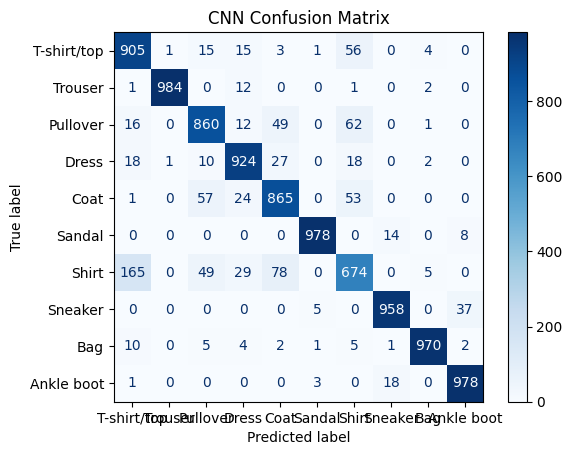

🔹 Classification Report (CNN Model):

              precision    recall  f1-score   support

 T-shirt/top     0.8102    0.9050    0.8550      1000
     Trouser     0.9980    0.9840    0.9909      1000
    Pullover     0.8635    0.8600    0.8617      1000
       Dress     0.9059    0.9240    0.9149      1000
        Coat     0.8447    0.8650    0.8547      1000
      Sandal     0.9899    0.9780    0.9839      1000
       Shirt     0.7756    0.6740    0.7212      1000
     Sneaker     0.9667    0.9580    0.9623      1000
         Bag     0.9858    0.9700    0.9778      1000
  Ankle boot     0.9541    0.9780    0.9659      1000

    accuracy                         0.9096     10000
   macro avg     0.9094    0.9096    0.9088     10000
weighted avg     0.9094    0.9096    0.9088     10000


✅ Overall CNN Performance Metrics:
Accuracy       : 90.4110
Precision      : 90.0800
Recall         : 90.1050
F1-Score       : 90.1000
Validation Loss: 25.4360


In [14]:
from sklearn.metrics import (
    confusion_matrix, classification_report, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score
)
import matplotlib.pyplot as plt
import numpy as np

# ---- 0️⃣ Define class names (Fashion MNIST) ----
class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

# ---- 1️⃣ Make predictions on the test set ----
y_pred_probs = model2.predict(x_test_cnn)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# ---- 2️⃣ Confusion Matrix ----
cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues', values_format='d')
plt.title("CNN Confusion Matrix")
plt.show()

# ---- 3️⃣ Classification Report (Accuracy, Precision, Recall, F1-Score) ----
report = classification_report(y_test, y_pred_classes, target_names=class_names, digits=4)
print("🔹 Classification Report (CNN Model):\n")
print(report)

# ---- 4️⃣ Evaluate model to get test loss (if not already done) ----
test_loss, test_acc = model2.evaluate(x_test_cnn, y_test, verbose=0)

# ---- 5️⃣ Extract key metrics ----
acc = accuracy_score(y_test, y_pred_classes)
prec = precision_score(y_test, y_pred_classes, average='weighted')
rec = recall_score(y_test, y_pred_classes, average='weighted')
f1 = f1_score(y_test, y_pred_classes, average='weighted')

print(f"\n✅ Overall CNN Performance Metrics:")
print(f"Accuracy       : {acc:.4f}")
print(f"Precision      : {prec:.4f}")
print(f"Recall         : {rec:.4f}")
print(f"F1-Score       : {f1:.4f}")
print(f"Validation Loss: {test_loss:.4f}")


# **Visualize Accuracy and Loss**

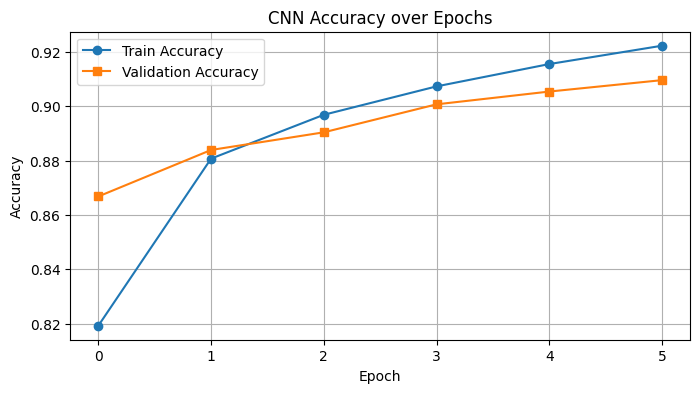

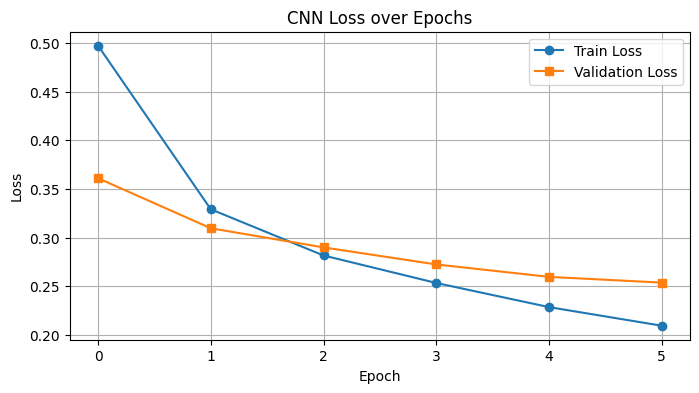

In [10]:
plt.figure(figsize=(8,4))
plt.plot(history2.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history2.history['val_accuracy'], label='Validation Accuracy', marker='s')
plt.title("CNN Accuracy over Epochs")
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,4))
plt.plot(history2.history['loss'], label='Train Loss', marker='o')
plt.plot(history2.history['val_loss'], label='Validation Loss', marker='s')
plt.title("CNN Loss over Epochs")
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


# **Custom Prediction**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


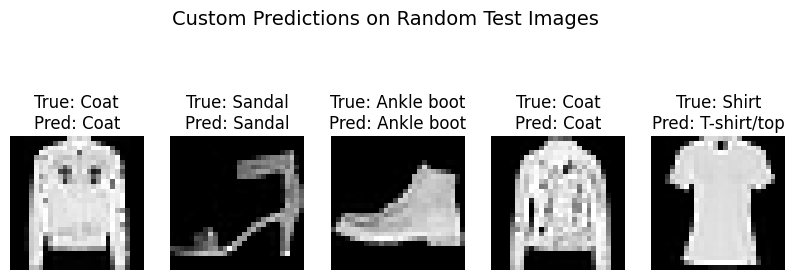

In [11]:
class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

# Select random test samples for prediction
num_samples = 5
indices = np.random.choice(len(x_test_cnn), num_samples, replace=False)
sample_images = x_test_cnn[indices]
sample_labels = y_test[indices]

# Make predictions
predictions = model2.predict(sample_images)
predicted_classes = np.argmax(predictions, axis=1)

# Display results
plt.figure(figsize=(10, 4))
for i in range(num_samples):
    plt.subplot(1, num_samples, i+1)
    plt.imshow(sample_images[i].reshape(28,28), cmap='gray')
    plt.title(f"True: {class_names[sample_labels[i]]}\nPred: {class_names[predicted_classes[i]]}")
    plt.axis('off')
plt.suptitle("Custom Predictions on Random Test Images", fontsize=14)
plt.show()

# **Predict on a Custom Image**

📤 Please upload an image (e.g., shirt, shoe, bag, etc.) to test the model.


Saving download (2).jpg to download (2).jpg
✅ Uploaded file: download (2).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


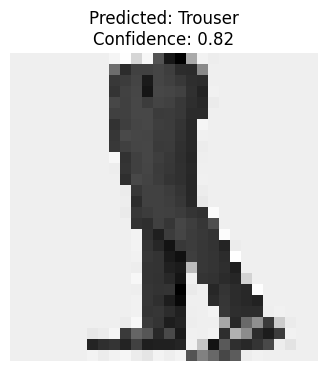

✅ Predicted Class: Trouser
🔢 Confidence: 81.72%


In [12]:
from tensorflow.keras.preprocessing import image
from google.colab import files
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

# --- Step 1: Upload an Image ---
print("📤 Please upload an image (e.g., shirt, shoe, bag, etc.) to test the model.")
uploaded = files.upload()

# Get the uploaded image filename
for img_path in uploaded.keys():
    print(f"✅ Uploaded file: {img_path}")

    # --- Step 2: Load and Preprocess the Image ---
    img = image.load_img(img_path, color_mode='grayscale', target_size=(28, 28))
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0  # normalize
    img_array = np.expand_dims(img_array, axis=0)  # reshape for CNN

    # --- Step 3: Make Prediction ---
    prediction = model2.predict(img_array)
    predicted_class = np.argmax(prediction)
    confidence = np.max(prediction)

    # --- Step 4: Define Class Names ---
    class_names = [
        'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
        'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
    ]

    # --- Step 5: Display Result ---
    plt.figure(figsize=(4, 4))
    plt.imshow(img_array[0].reshape(28, 28), cmap='gray')
    plt.title(f"Predicted: {class_names[predicted_class]}\nConfidence: {confidence:.2f}")
    plt.axis('off')
    plt.show()

    print(f"✅ Predicted Class: {class_names[predicted_class]}")
    print(f"🔢 Confidence: {confidence*100:.2f}%")